# Quantum Fourier Transform

* f(k) = integral [-inf, inf] dx e^(ikx) f(x) - FT
* f(x) = integral [-inf, inf] dk/2pi e^(-ikx) f(k) - IFT

CD/CD - function & Fourier series, n - domain of all intigers
DD

FFT on 1 is either Kronecker delta or Dirac delta

Gibbs phenomenon: ringing artifacts on the discontinuity

## Fast Fourier Transform (DD)

1. We need to hardcode the twiddle factors (exponens)
2. Classical algorithm created by Cooley and Tuckey in 1965 (n bitwise transforms)
3. Green stripes - proper basis in the moment, be can apply all but b = n - 1 - a
4. The complementary order! because of the sum
5. Applying Hadamard gate

## Controlled phase gate

* the orders of bits for x and k are swaped. 6 of initial basis corresponds to 0 to final basis (k).

* Shor algorithm - farctorizing big numbers. works only in theory

In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np

Code QFT, draw a circuit, and realize some modular addition of a
constant y
* small number of qubits is faster
* use AER simulator cp and h gates
* adding a constant : apply RZπy /2m to qubit xm (kn−m−1)

In [ ]:
# gates to be used in the QFT circuit
#qc.h(q)[0]  # Hadamard gate on qubit 0
#qc.cp(theta, control_qubit, target_qubit)

## QTF & Inverse QFT

In [146]:
def qft(circuit, n):
    if n == 0:
        return circuit
    n -= 1
    circuit.h(n)
    for qubit in range(n):
        circuit.cp(np.pi/2**(n-qubit), qubit, n)
    

    qft(circuit, n)

# no swaps
def create_qft_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits)
    qft(qc, num_qubits)
        
    return qc

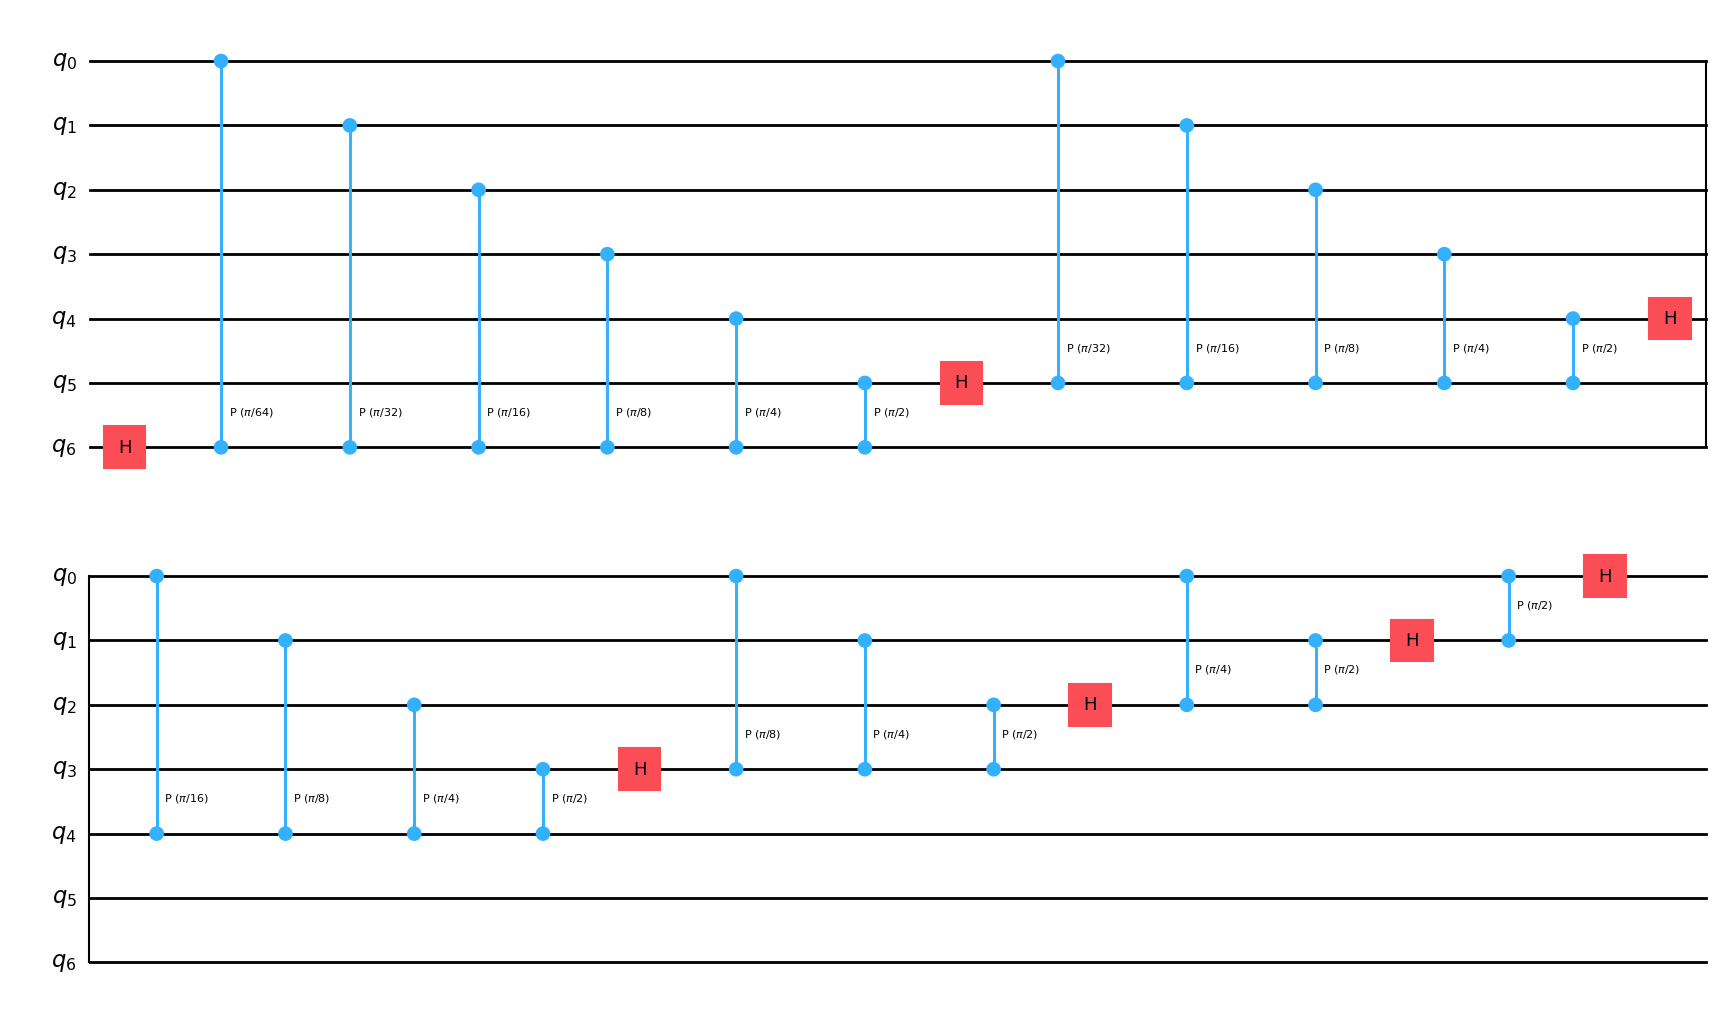

In [147]:
qc = create_qft_circuit(7)
qc.draw("mpl")

In [ ]:
def iqft(circuit, n, i=0):
    if i == n:
        return circuit
    circuit.h(i)
    
    k = 1
    for target in range(i + 1, n):
        angle = -np.pi / (2**k)
        circuit.cp(angle, i, target)
        k += 1

    if i < n - 1:
        circuit.barrier()
        
    iqft(circuit, n, i + 1)

def create_iqft_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits)
    iqft(qc, num_qubits)
    
    return qc

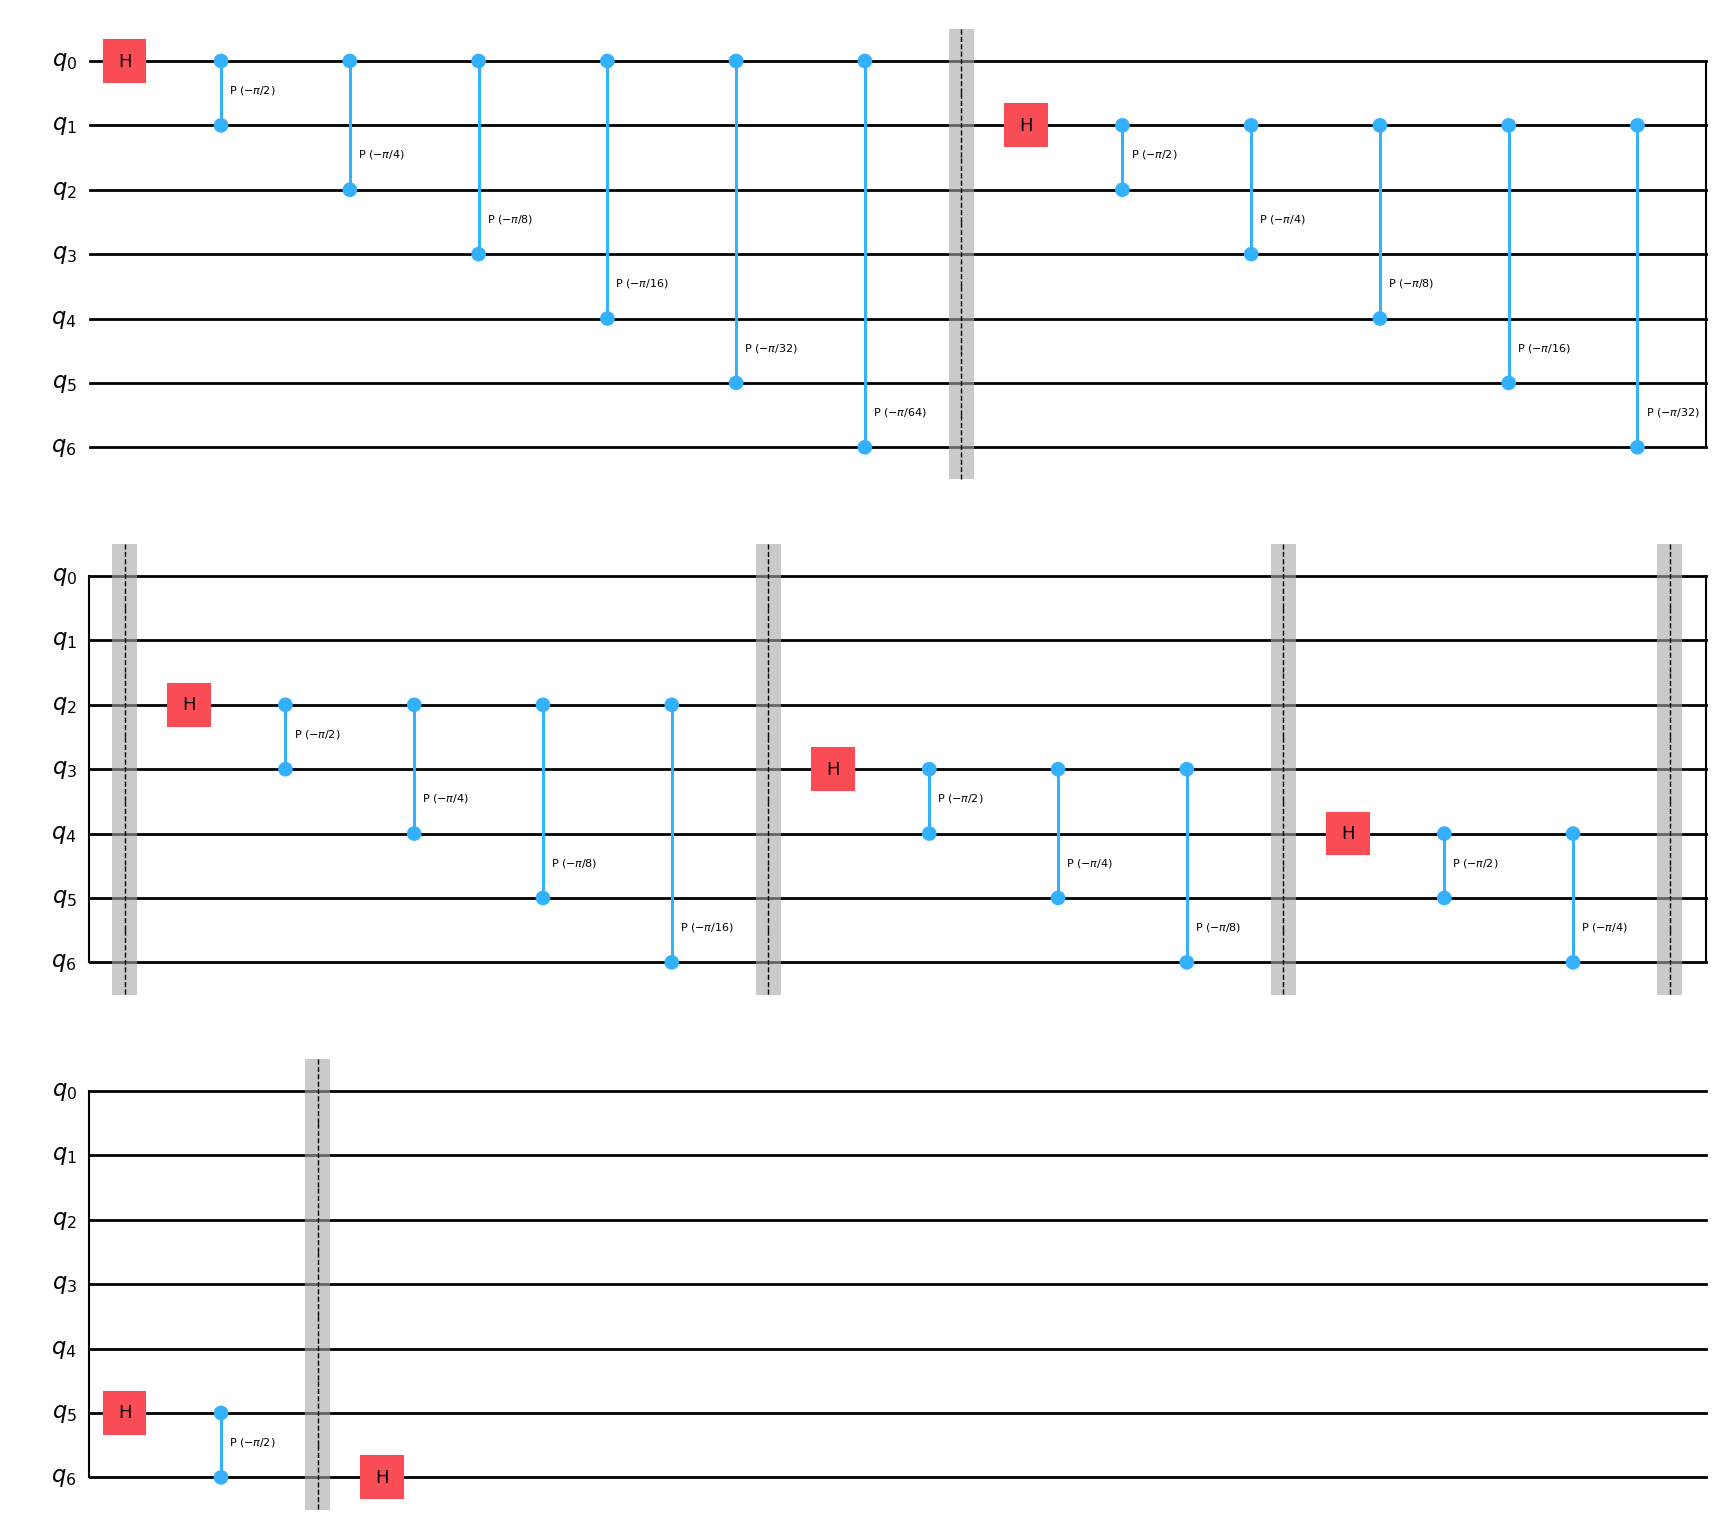

In [149]:
qc_inv = create_iqft_circuit(7)
qc_inv.draw("mpl")

## Add modular

In [150]:
def create_circuit_add_modular(val_x=0, val_y=0, num_qubits=7):
    
    qc = QuantumCircuit(num_qubits, num_qubits)

    bin_x = format(val_x, f'0{num_qubits}b')[::-1]
    for i in range(num_qubits):
        if bin_x[i] == '1': 
            qc.x(i)

    qc.barrier()


    qft(qc, num_qubits)
    for i in range(num_qubits // 2):
        qc.swap(i, num_qubits - 1 - i)
        
    qc.barrier()

    total_to_add = val_y 
    
    for i in range(num_qubits):
        angle = (2 * np.pi * total_to_add) / (2**(num_qubits - i))
        qc.p(angle, i)
        
    qc.barrier()

    for i in range(num_qubits // 2):
        qc.swap(i, num_qubits - 1 - i)
        
    iqft(qc, num_qubits)

    qc.barrier()
    qc.measure(range(num_qubits), range(num_qubits)) 

    return qc


In [151]:
def run_and_plot(val_x, val_y, num_qubits, backend=AerSimulator(), N=1000):
    
    circuit = create_circuit_add_modular(val_x,val_y,num_qubits)
    transpiled_circuit = transpile(circuit, backend)
    job = backend.run(transpiled_circuit, shots=N)
    result = job.result()
    counts = result.get_counts(transpiled_circuit)


    bin_result = list(counts.keys())[0]
    dec_result = int(bin_result, 2)
    
    print("=" * 50)
    print(f"Task: {val_x} + {val_y} on {num_qubits} qubits")
    print("-" * 50)
    print(f"Results: {counts}")
    print(f"Result binary:  {bin_result}")
    print(f"Result decimal: {dec_result}")

    fig = circuit.draw("mpl")
    
    return counts, fig


## Test

Task: 17 + 29 on 7 qubits
--------------------------------------------------
Results: {'0101110': 1000}
Result binary:  0101110
Result decimal: 46


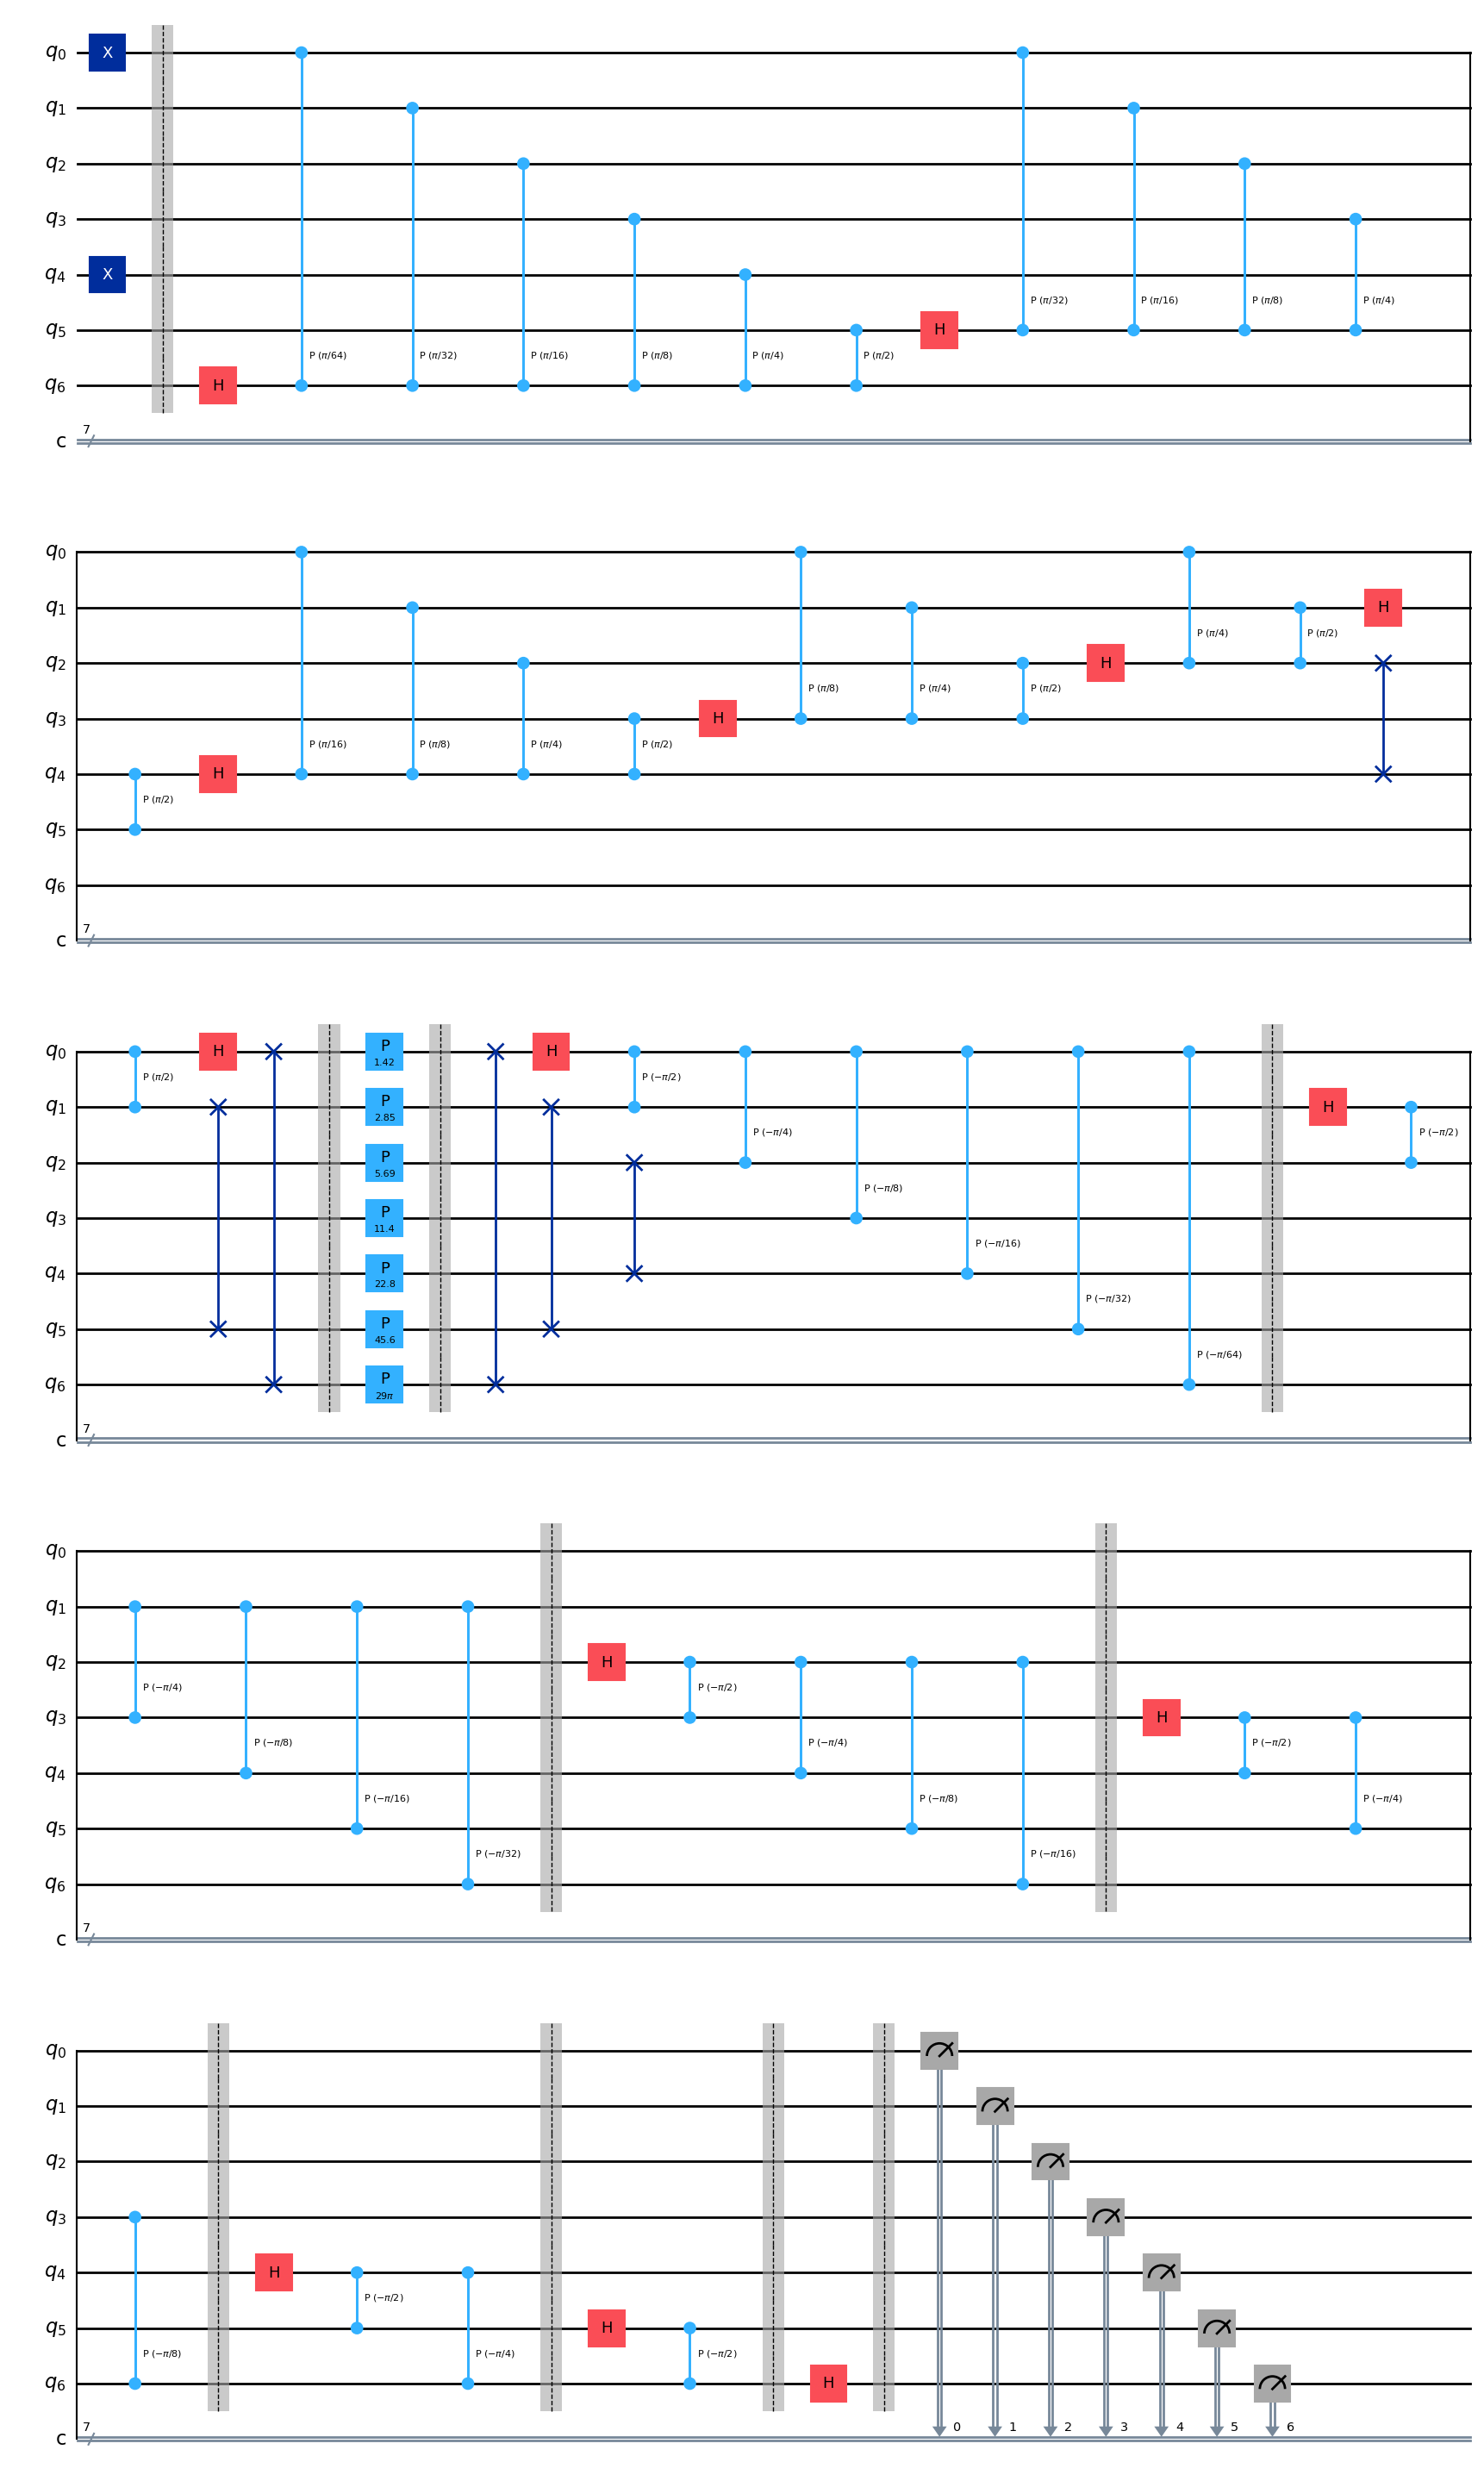

In [156]:
counts, fig = run_and_plot(val_x=17, val_y=29, num_qubits=7)
fig